In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Consider Net as solution u_theta(x, t)

In [30]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 5)
        self.fc2 = nn.Linear(5, 5)
        self.fc3 = nn.Linear(5, 5)
        self.fc4 = nn.Linear(5, 5)
        self.fc5 = nn.Linear(5, 5)
        self.fc6 = nn.Linear(5, 1)

    def forward(self, x, t):
        inputs = torch.cat((x, t), 1)
        h1 = torch.tanh(self.fc1(inputs))
        h2 = torch.tanh(self.fc2(h1))
        h3 = torch.tanh(self.fc3(h2))
        h4 = torch.tanh(self.fc4(h3))
        h5 = torch.tanh(self.fc5(h4))
        h6 = self.fc6(h5)
        return h6

# Create Model

In [31]:
model = Net().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
def f(x, t, net):
    u = net(x, t)
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t - 2*u_x - u  

## Data from Boundary Conditions

In [33]:
x_bc = np.random.uniform(0.0, 2.0 , (1,500))
t_bc = np.zeros((1,500))
u_bc = 6 * np.exp(-3*x_bc)

x_c = np.random.uniform(0.0, 2.0 , (1,500))
t_c = np.random.uniform(0.0, 1.0 , (1,500))
u_c = np.zeros((1,500))

In [34]:
num_epochs = 10000

inputs_xb = torch.tensor(x_bc, dtype=torch.float32, requires_grad=False).view(-1, 1).to(device)
inputs_tb = torch.tensor(t_bc, dtype=torch.float32, requires_grad=False).view(-1, 1).to(device)
output_b = torch.tensor(u_bc, dtype=torch.float32, requires_grad=False).view(-1, 1).to(device)

inputs_x = torch.tensor(x_c, dtype=torch.float32, requires_grad=True).view(-1, 1).to(device)
inputs_t = torch.tensor(t_c, dtype=torch.float32, requires_grad=True).view(-1, 1).to(device)
output = torch.tensor(u_c, dtype=torch.float32).view(-1, 1).to(device)

for epoch in range(num_epochs):
    optimizer.zero_grad()

    loss_ub = criterion(model(inputs_xb, inputs_tb), output_b)

    loss_f = criterion(f(inputs_x, inputs_t, model), output)

    loss = loss_ub + loss_f

    loss.backward()
    optimizer.step()
    if (epoch+1) % 500 == 0:
        print(f"Epoch: {epoch+1}/[{num_epochs}], Loss: {loss.item():.4f}")

Epoch: 500/[10000], Loss: 0.3853
Epoch: 1000/[10000], Loss: 0.0917
Epoch: 1500/[10000], Loss: 0.0164
Epoch: 2000/[10000], Loss: 0.0046
Epoch: 2500/[10000], Loss: 0.0017
Epoch: 3000/[10000], Loss: 0.0008
Epoch: 3500/[10000], Loss: 0.0005
Epoch: 4000/[10000], Loss: 0.0003
Epoch: 4500/[10000], Loss: 0.0002
Epoch: 5000/[10000], Loss: 0.0001
Epoch: 5500/[10000], Loss: 0.0001
Epoch: 6000/[10000], Loss: 0.0001
Epoch: 6500/[10000], Loss: 0.0000
Epoch: 7000/[10000], Loss: 0.0000
Epoch: 7500/[10000], Loss: 0.0000
Epoch: 8000/[10000], Loss: 0.0000
Epoch: 8500/[10000], Loss: 0.0001
Epoch: 9000/[10000], Loss: 0.0000
Epoch: 9500/[10000], Loss: 0.0000
Epoch: 10000/[10000], Loss: 0.0000


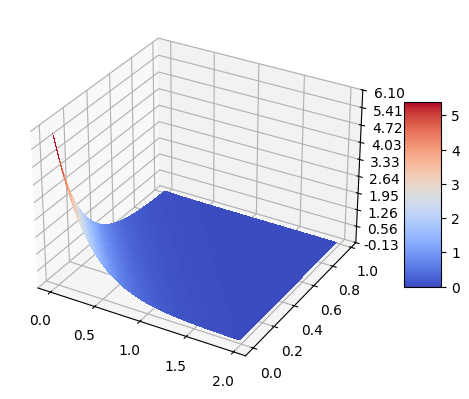

In [42]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = np.arange(0, 2, 0.02)
t = np.arange(0, 1, 0.02)

ms_x, ms_t = np.meshgrid(x, t)

x = np.ravel(ms_x).reshape(-1, 1)
t = np.ravel(ms_t).reshape(-1, 1)

input_x = torch.tensor(x, dtype=torch.float32, requires_grad=True).to(device)
input_t = torch.tensor(t, dtype=torch.float32, requires_grad=True).to(device)
output = model(input_x, input_t)
u = output.detach().cpu().numpy()
ms_u = u.reshape(ms_x.shape)

surf = ax.plot_surface(ms_x, ms_t, ms_u, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()